<a href="https://colab.research.google.com/github/AROO-6/Thiranex_task/blob/main/Thiranex_project_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
pip install plotly nbformat kaleido --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.6/55.6 kB 1.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.6/52.6 kB 2.2 MB/s eta 0:00:00


In [2]:
import pandas as pd
import numpy as np

np.random.seed(42)
n = 52841

categories = ['Electronics', 'Clothing', 'Groceries', 'Home & Garden', 'Sports']
segments   = ['Champions', 'Loyal', 'At-Risk', 'Lost']

dates = pd.date_range('2022-01-01', '2024-12-31', periods=n)

# Seasonal multiplier (Q4 boost)
month_mult = {1:0.85,2:0.80,3:0.92,4:0.95,5:0.97,6:1.00,
              7:1.02,8:1.04,9:1.06,10:1.08,11:1.18,12:1.35}

df = pd.DataFrame({
    'date':       dates,
    'category':   np.random.choice(categories, n, p=[0.34,0.22,0.18,0.14,0.12]),
    'segment':    np.random.choice(segments,   n, p=[0.18,0.27,0.31,0.24]),
    'quantity':   np.random.randint(1, 8, n),
})

# Price by category
price_map = {'Electronics':320,'Clothing':85,'Groceries':28,'Home & Garden':110,'Sports':95}
df['unit_price'] = df['category'].map(price_map) * np.random.uniform(0.7, 1.4, n)

# Apply seasonal multiplier
df['month'] = df['date'].dt.month
df['revenue'] = df['unit_price'] * df['quantity'] * df['month'].map(month_mult)
df['revenue'] = df['revenue'].round(2)

# Margin by category
margin_map = {'Electronics':0.24,'Clothing':0.31,'Groceries':0.08,'Home & Garden':0.19,'Sports':0.27}
df['margin'] = df['category'].map(margin_map)
df['profit'] = (df['revenue'] * df['margin']).round(2)

df['year'] = df['date'].dt.year
df.head()

,date,category,segment,quantity,unit_price,month,revenue,margin,profit,year
0,2022-01-01 00:00:00.000000000,Clothing,Loyal,4,99.900115,1,339.66,0.31,105.29,2022
1,2022-01-01 00:29:50.461771385,Sports,At-Risk,4,82.390149,1,280.13,0.27,75.64,2022
2,2022-01-01 00:59:40.923542770,Groceries,Champions,1,30.674528,1,26.07,0.08,2.09,2022
3,2022-01-01 01:29:31.385314155,Groceries,Loyal,4,21.117230,1,71.80,0.08,5.74,2022
4,2022-01-01 01:59:21.847085541,Electronics,Loyal,7,359.834205,1,2141.01,0.24,513.84,2022


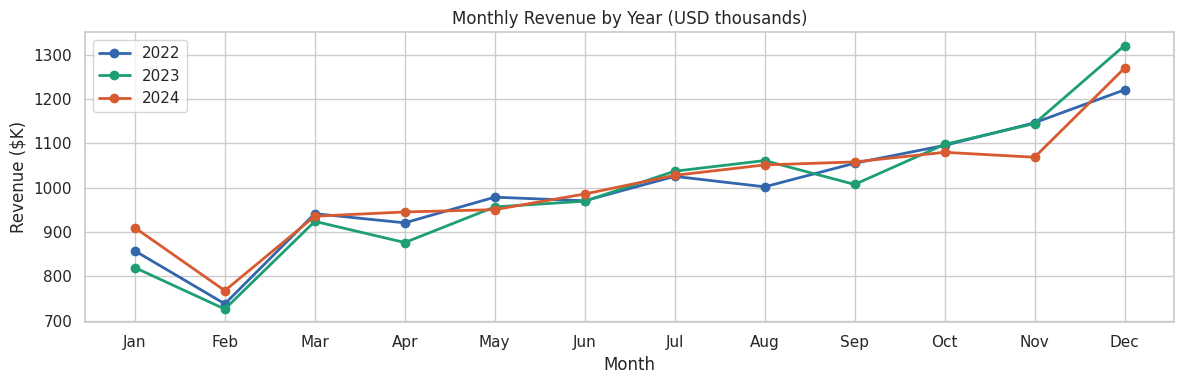

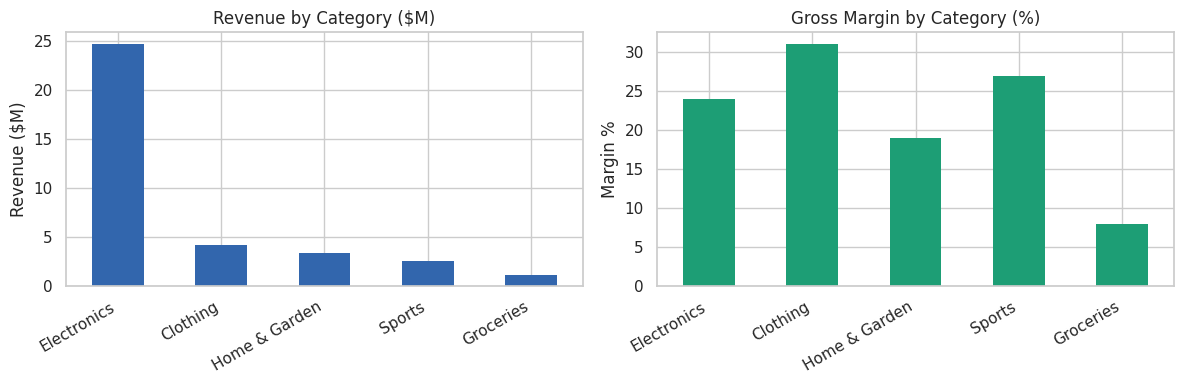

                   revenue      profit  margin_pct
category                                          
Electronics    24626705.06  5910409.60        24.0
Clothing        4222276.70  1308905.89        31.0
Home & Garden   3401307.69   646248.23        19.0
Sports          2549521.63   688370.78        27.0
Groceries       1141005.38    91280.17         8.0


In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid', palette='muted')

# --- Monthly revenue trend ---
monthly = df.groupby(['year', df['date'].dt.month])['revenue'].sum().reset_index()
monthly.columns = ['year','month','revenue']

fig, ax = plt.subplots(figsize=(12, 4))
colors = {2022:'#3266ad', 2023:'#1d9e75', 2024:'#d85a30'}
for yr, grp in monthly.groupby('year'):
    ax.plot(grp['month'], grp['revenue']/1000, marker='o', label=str(yr),
            color=colors[yr], linewidth=2)
ax.set(title='Monthly Revenue by Year (USD thousands)',
       xlabel='Month', ylabel='Revenue ($K)',
       xticks=range(1,13),
       xticklabels=['Jan','Feb','Mar','Apr','May','Jun',
                    'Jul','Aug','Sep','Oct','Nov','Dec'])
ax.legend()
plt.tight_layout()
plt.show()

# --- Category revenue & margin ---
cat_stats = df.groupby('category').agg(
    revenue=('revenue','sum'),
    profit=('profit','sum')
).assign(margin_pct=lambda x: x['profit']/x['revenue']*100).sort_values('revenue', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
cat_stats['revenue'].div(1e6).plot(kind='bar', ax=axes[0], color='#3266ad', edgecolor='none')
axes[0].set(title='Revenue by Category ($M)', xlabel='', ylabel='Revenue ($M)')
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=30, ha='right')

cat_stats['margin_pct'].plot(kind='bar', ax=axes[1], color='#1d9e75', edgecolor='none')
axes[1].set(title='Gross Margin by Category (%)', xlabel='', ylabel='Margin %')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=30, ha='right')
plt.tight_layout()
plt.show()

print(cat_stats.round(2))

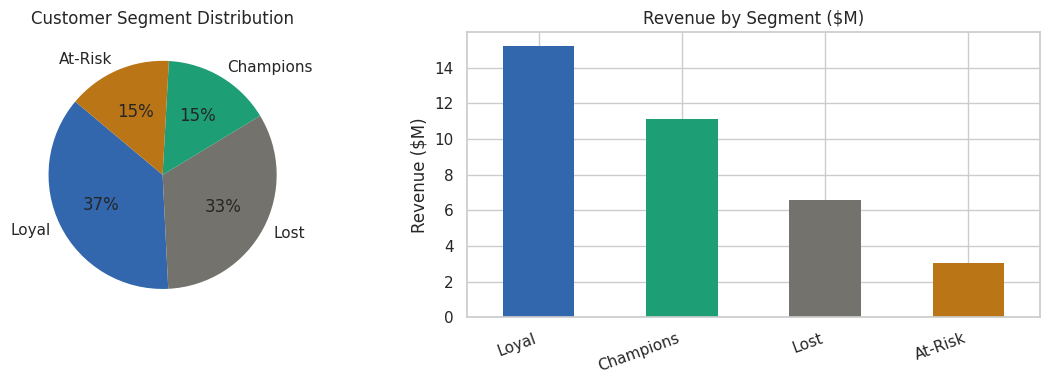

           recency  frequency  monetary
segment                                
At-Risk      571.8        3.2    2077.6
Champions    107.3        8.6    7236.2
Lost         157.3        3.7    2004.4
Loyal        133.2        6.2    4144.8


In [4]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# Build RFM table (simulate customer IDs)
df['customer_id'] = np.random.randint(1000, 11000, n)
snapshot = pd.Timestamp('2025-01-01')

rfm = df.groupby('customer_id').agg(
    recency  = ('date', lambda x: (snapshot - x.max()).days),
    frequency= ('date', 'count'),
    monetary = ('revenue', 'sum')
).reset_index()

# Scale & cluster
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm[['recency','frequency','monetary']])

kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
rfm['cluster'] = kmeans.fit_predict(rfm_scaled)

# Label clusters by monetary value
cluster_labels = rfm.groupby('cluster')['monetary'].mean().sort_values(ascending=False)
label_map = {c: l for c, l in zip(cluster_labels.index, ['Champions','Loyal','At-Risk','Lost'])}
rfm['segment'] = rfm['cluster'].map(label_map)

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
colors = {'Champions':'#1d9e75','Loyal':'#3266ad','At-Risk':'#ba7517','Lost':'#73726c'}

seg_counts = rfm['segment'].value_counts()
seg_counts.plot(kind='pie', ax=axes[0], colors=[colors[s] for s in seg_counts.index],
                autopct='%1.0f%%', startangle=140, wedgeprops={'linewidth':0})
axes[0].set(title='Customer Segment Distribution', ylabel='')

seg_rev = rfm.groupby('segment')['monetary'].sum().sort_values(ascending=False)
seg_rev.div(1e6).plot(kind='bar', ax=axes[1],
                      color=[colors[s] for s in seg_rev.index], edgecolor='none')
axes[1].set(title='Revenue by Segment ($M)', xlabel='', ylabel='Revenue ($M)')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=20, ha='right')
plt.tight_layout()
plt.show()

print(rfm.groupby('segment')[['recency','frequency','monetary']].mean().round(1))

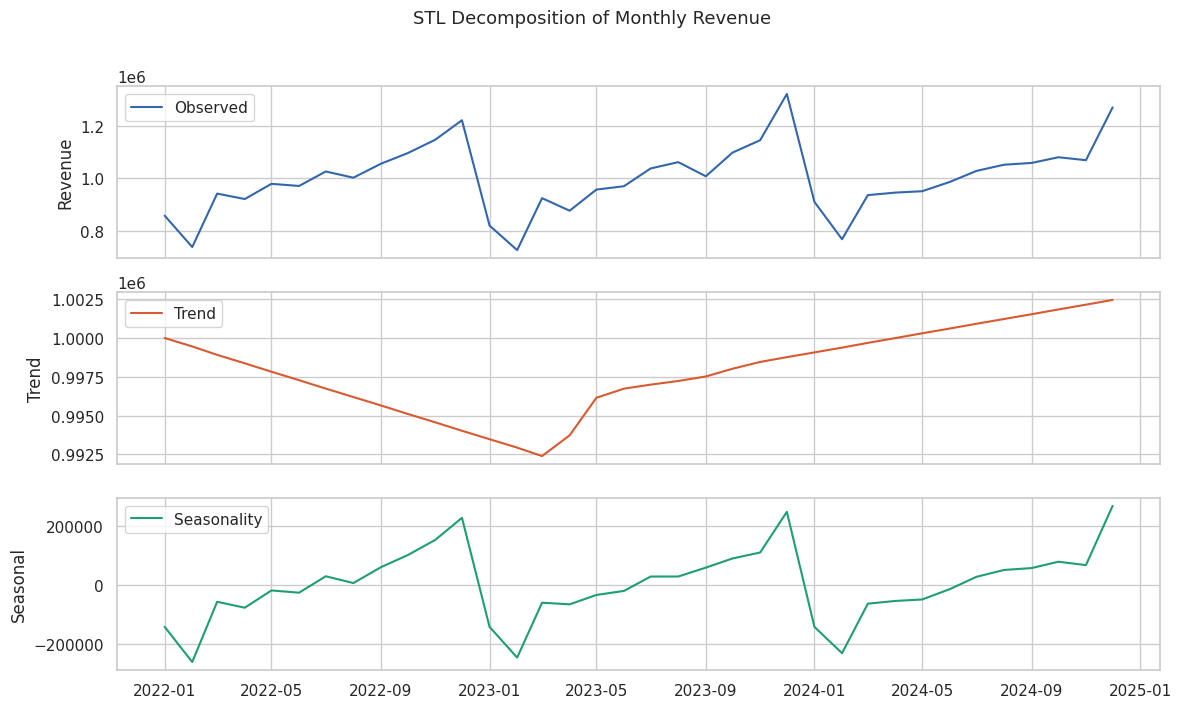

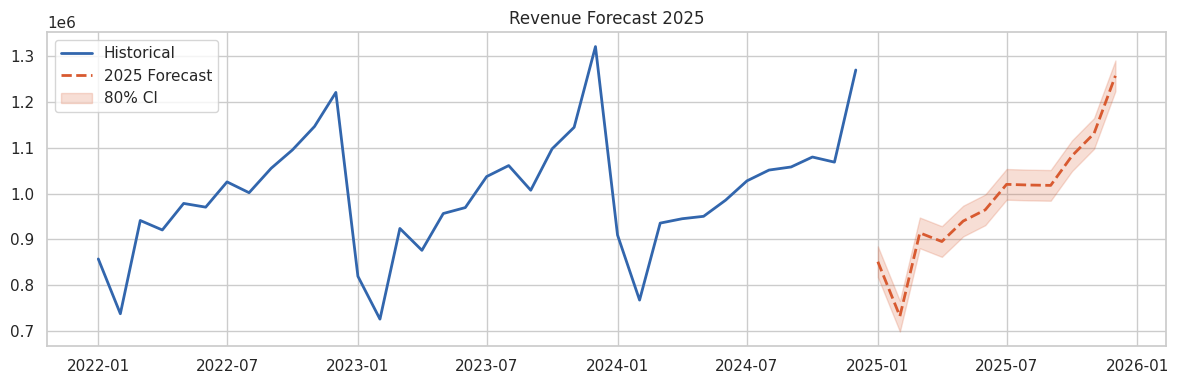


2025 Projected Revenue: $11.83M


In [5]:
from statsmodels.tsa.seasonal import STL

# Monthly series
ts = df.groupby(df['date'].dt.to_period('M'))['revenue'].sum()
ts.index = ts.index.to_timestamp()

# STL decomposition
stl = STL(ts, period=12, robust=True)
result = stl.fit()

fig, axes = plt.subplots(3, 1, figsize=(12, 7), sharex=True)
axes[0].plot(ts, color='#3266ad', linewidth=1.5, label='Observed')
axes[0].set_ylabel('Revenue'); axes[0].legend()
axes[1].plot(result.trend, color='#d85a30', linewidth=1.5, label='Trend')
axes[1].set_ylabel('Trend'); axes[1].legend()
axes[2].plot(result.seasonal, color='#1d9e75', linewidth=1.5, label='Seasonality')
axes[2].set_ylabel('Seasonal'); axes[2].legend()
fig.suptitle('STL Decomposition of Monthly Revenue', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

# Simple 12-month extrapolation
import warnings
warnings.filterwarnings('ignore')
from statsmodels.tsa.holtwinters import ExponentialSmoothing

model = ExponentialSmoothing(ts, trend='add', seasonal='add', seasonal_periods=12)
fit   = model.fit()
forecast = fit.forecast(12)

plt.figure(figsize=(12, 4))
plt.plot(ts, color='#3266ad', linewidth=2, label='Historical')
plt.plot(forecast, color='#d85a30', linewidth=2, linestyle='--', label='2025 Forecast')
# Rough 80% CI (±1.28 * residual std)
std = np.std(fit.resid)
plt.fill_between(forecast.index,
                 forecast - 1.28*std,
                 forecast + 1.28*std,
                 alpha=0.2, color='#d85a30', label='80% CI')
plt.title('Revenue Forecast 2025')
plt.legend(); plt.tight_layout(); plt.show()

print(f"\n2025 Projected Revenue: ${forecast.sum()/1e6:.2f}M")

In [6]:
# Save cleaned dataset and RFM table
df.to_csv('supermart_transactions.csv', index=False)
rfm.to_csv('rfm_segments.csv', index=False)
print("Files saved — download via Files panel on the left sidebar.")

Files saved — download via Files panel on the left sidebar.
